In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable 
from matplotlib.colors import LogNorm, Normalize

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
arr     = np.load("../../data/social_impact/beta.npy", allow_pickle=True)
ops     = np.load("../../data/social_impact/beta_opinion.npy", allow_pickle=True)
params  = np.load("../../data/social_impact/beta_params.npy", allow_pickle=True)
beta_l = params[:, 3]
avg_op  = np.mean(np.abs(arr), axis=1)
std_op  = np.std(np.abs(arr), axis=1)

Text(0.5, 0.98, 'N = 80, Erdos-Renyi Graph @ p_con = 1.0, w/o Noise')

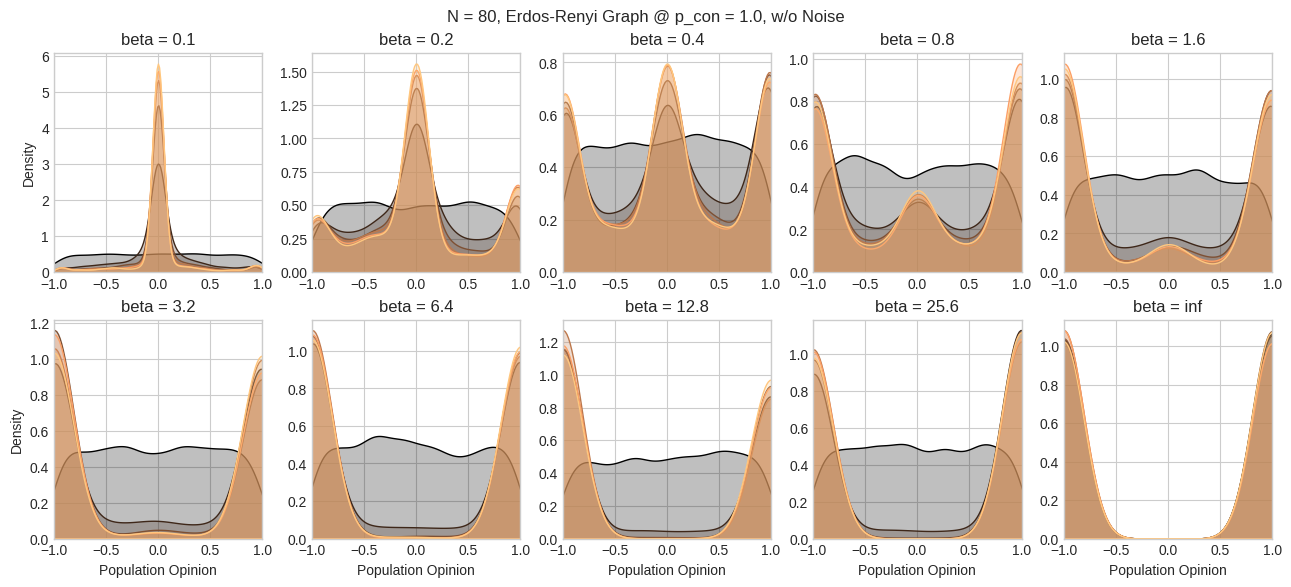

In [4]:
fig = plt.figure(dpi=100, layout='constrained')
fig.set_figwidth(fig.get_figwidth()*2)
fig.set_figheight(fig.get_figheight()*1.2)

steps   = [0,199,399,599,799,999]
cm      = plt.get_cmap('copper')
norm    = Normalize(vmin=min(steps), vmax=(max(steps)))

for n, beta in enumerate(beta_l):
    ax = fig.add_subplot(2,5,n+1)
    for i in steps:
        ax = sns.kdeplot(ops[n,:,i,:].flatten(), ax=ax, fill=True, color=cm(norm(i)))

    ax.set_xlabel('Population Opinion')
    ax.set_title(f"beta = {beta}")
    ax.set_xlim(-1,1)
    if n % 5 != 0:
        ax.set_ylabel('')
    if n < 5:
        ax.set_xlabel('')

fig.suptitle("N = 80, Erdos-Renyi Graph @ p_con = 1.0, w/o Noise")

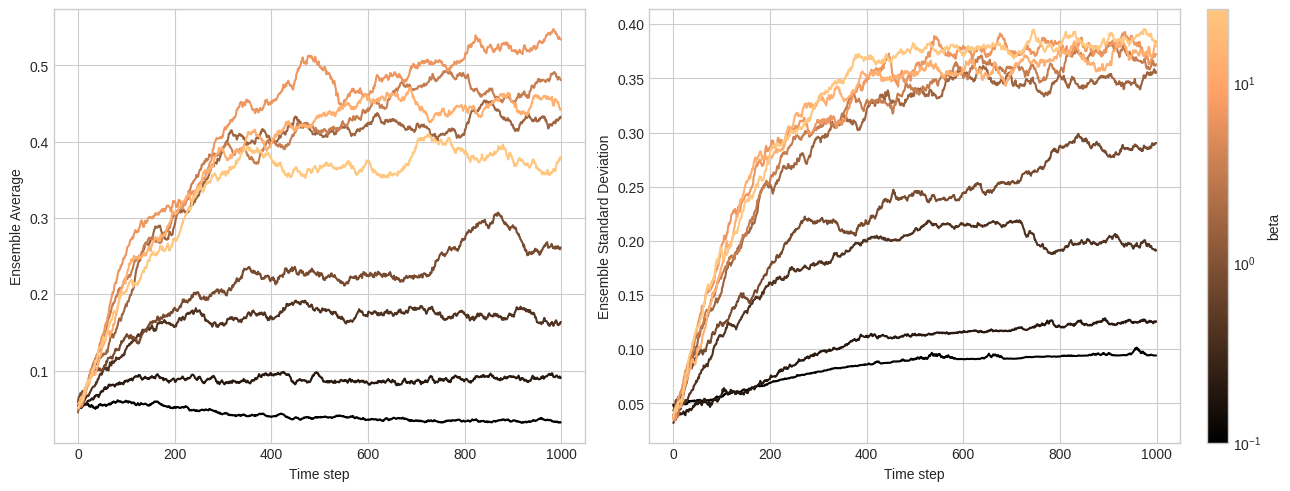

In [5]:
fig     = plt.figure(dpi=100, layout='constrained')
fig.set_figwidth(fig.get_figwidth()*2)
ax1     = fig.add_subplot(1,2,1)
ax2     = fig.add_subplot(1,2,2)
cm      = plt.get_cmap('copper')
norm    = LogNorm(vmin=min(beta_l), vmax=max(beta_l[:-1]))
sm      = ScalarMappable(cmap=cm, norm=norm)
sm.set_array([])

for i in range(len(beta_l)):
    ax1.plot(avg_op[i,:], color=cm(norm(beta_l[i])))
    ax2.plot(std_op[i,:], color=cm(norm(beta_l[i])))

ax1.set_xlabel("Time step")
ax1.set_ylabel("Ensemble Average")

ax2.set_xlabel("Time step")
ax2.set_ylabel("Ensemble Standard Deviation")

cbar = fig.colorbar(sm, ax=ax2, label='beta')